# 构建神经网络识别MNIST数据

了解数据集：
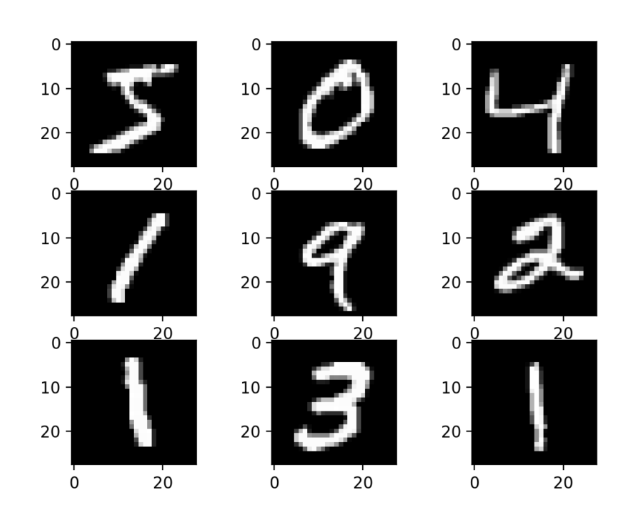

In [10]:
import numpy as np

In [11]:
# 准备数据
train_X, test_X, train_y, test_y = np.load(
    'file/mnist.npy', allow_pickle=True)

In [12]:
train_X.shape

(60000, 28, 28)

In [13]:
test_X.shape

(10000, 28, 28)

将 [60000, 28, 28]结构改为 [60000, 784]:

In [14]:
x_train = train_X.reshape(60000, 28*28).astype(np.float32)
x_test = test_X.reshape(10000, 28*28).astype(np.float32)

## 1. 准备数据

转换成`tensor`：

In [16]:
import torch

In [17]:
x_train, y_train, x_test, y_test = map(
    torch.tensor, (x_train, train_y, x_test, test_y)
)

## 2. 构建网络

确定神经网络框架结构：

假设输入层为784个神经元，输出层10个神经元，没有隐藏层

一、准备：

初始化bias和 weights

二、迭代训练过程

1. 前向传播
2. 计算损失loss
3. loss.backward（）反向传播
4. 更新参数（权重和偏置）


In [18]:
#1. 初始化bias和weights
bias = torch.zeros(10, requires_grad=True, dtype=torch.float32)
weights = torch.randn(784, 10, requires_grad=True)
lr = 0.003

In [19]:
for i in range(500):
    # 前向传播
    y_pred = x_train @ weights + bias
    # 计算损失,交叉熵
    loss = torch.nn.functional.cross_entropy(y_pred, y_train)
    print(i, loss)
    # 反向传播
    loss.backward()
    # 更新参数
    weights.data.add_(-weights.grad * lr)
    bias.data.add_(-bias.grad * lr)
    weights.grad.zero_()
    bias.grad.zero_()

0 tensor(3570.8298, grad_fn=<NllLossBackward>)
1 tensor(2750.1501, grad_fn=<NllLossBackward>)
2 tensor(2363.1580, grad_fn=<NllLossBackward>)
3 tensor(2075.5496, grad_fn=<NllLossBackward>)
4 tensor(1831.3052, grad_fn=<NllLossBackward>)
5 tensor(1630.9552, grad_fn=<NllLossBackward>)
6 tensor(1470.8650, grad_fn=<NllLossBackward>)
7 tensor(1339.2466, grad_fn=<NllLossBackward>)
8 tensor(1227.4519, grad_fn=<NllLossBackward>)
9 tensor(1132.3601, grad_fn=<NllLossBackward>)
10 tensor(1050.8363, grad_fn=<NllLossBackward>)
11 tensor(980.5615, grad_fn=<NllLossBackward>)
12 tensor(920.3669, grad_fn=<NllLossBackward>)
13 tensor(868.4337, grad_fn=<NllLossBackward>)
14 tensor(823.2686, grad_fn=<NllLossBackward>)
15 tensor(783.7270, grad_fn=<NllLossBackward>)
16 tensor(748.8283, grad_fn=<NllLossBackward>)
17 tensor(717.8304, grad_fn=<NllLossBackward>)
18 tensor(690.2213, grad_fn=<NllLossBackward>)
19 tensor(665.3793, grad_fn=<NllLossBackward>)
20 tensor(642.9481, grad_fn=<NllLossBackward>)
21 tensor(62

174 tensor(206.3698, grad_fn=<NllLossBackward>)
175 tensor(205.8383, grad_fn=<NllLossBackward>)
176 tensor(205.3112, grad_fn=<NllLossBackward>)
177 tensor(204.7885, grad_fn=<NllLossBackward>)
178 tensor(204.2693, grad_fn=<NllLossBackward>)
179 tensor(203.7535, grad_fn=<NllLossBackward>)
180 tensor(203.2422, grad_fn=<NllLossBackward>)
181 tensor(202.7365, grad_fn=<NllLossBackward>)
182 tensor(202.2345, grad_fn=<NllLossBackward>)
183 tensor(201.7357, grad_fn=<NllLossBackward>)
184 tensor(201.2416, grad_fn=<NllLossBackward>)
185 tensor(200.7517, grad_fn=<NllLossBackward>)
186 tensor(200.2660, grad_fn=<NllLossBackward>)
187 tensor(199.7840, grad_fn=<NllLossBackward>)
188 tensor(199.3049, grad_fn=<NllLossBackward>)
189 tensor(198.8314, grad_fn=<NllLossBackward>)
190 tensor(198.3604, grad_fn=<NllLossBackward>)
191 tensor(197.8933, grad_fn=<NllLossBackward>)
192 tensor(197.4317, grad_fn=<NllLossBackward>)
193 tensor(196.9724, grad_fn=<NllLossBackward>)
194 tensor(196.5163, grad_fn=<NllLossBac

345 tensor(152.4671, grad_fn=<NllLossBackward>)
346 tensor(152.2738, grad_fn=<NllLossBackward>)
347 tensor(152.0806, grad_fn=<NllLossBackward>)
348 tensor(151.8891, grad_fn=<NllLossBackward>)
349 tensor(151.6972, grad_fn=<NllLossBackward>)
350 tensor(151.5059, grad_fn=<NllLossBackward>)
351 tensor(151.3159, grad_fn=<NllLossBackward>)
352 tensor(151.1262, grad_fn=<NllLossBackward>)
353 tensor(150.9371, grad_fn=<NllLossBackward>)
354 tensor(150.7495, grad_fn=<NllLossBackward>)
355 tensor(150.5626, grad_fn=<NllLossBackward>)
356 tensor(150.3763, grad_fn=<NllLossBackward>)
357 tensor(150.1910, grad_fn=<NllLossBackward>)
358 tensor(150.0060, grad_fn=<NllLossBackward>)
359 tensor(149.8216, grad_fn=<NllLossBackward>)
360 tensor(149.6387, grad_fn=<NllLossBackward>)
361 tensor(149.4551, grad_fn=<NllLossBackward>)
362 tensor(149.2728, grad_fn=<NllLossBackward>)
363 tensor(149.0914, grad_fn=<NllLossBackward>)
364 tensor(148.9105, grad_fn=<NllLossBackward>)
365 tensor(148.7305, grad_fn=<NllLossBac